# Child model V&V: all-cause mortality

Version-free filename by convention: rerun against each model iteration's results and commit,
so run-over-run diffs fall out of git history. The LBWSG relative-risk and PAF checks that used
to live here moved to `child_lbwsg.ipynb`, which verifies them against a live `InteractiveContext`
of the child model.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from vivarium.artifact import Artifact

from lsff_utils import paths



In [2]:
location = "nigeria"
vehicle = "bouillon"
model_number = paths.MODEL_NUMBER  # the archived iteration to check; set explicitly to read an older one


In [3]:
# The run comes from the marker archive_last_run.sh copies beside the run directories,
# so this is the run the pipeline published -- no timestamp to paste in.
results_dir = paths.latest_results(
    paths.archive_root(paths.CHILD_RESULTS_ROOT, model_number), location, vehicle
)
artifact_dir = paths.artifact_path(
    paths.archive_root(paths.CHILD_ARTIFACT_ROOT, model_number), location, vehicle
)
print(f"{model_number} {vehicle}/{location}\n  results:  {results_dir}\n  artifact: {artifact_dir}")
art = Artifact(artifact_dir)

model1.2.4 bouillon/nigeria
  results:  /mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/results/model1.2.4/child/bouillon/nigeria/2026_09_09_22_02_21/results
  artifact: /mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/artifacts/model1.2.4/child/bouillon/nigeria.hdf


## All-cause mortality: sim vs artifact

The artifact rate is drawn as the step function the sim actually looks up (lookup interpolation
is order 0, so the rate is constant within each artifact age bin). The sim's measured
deaths / person-time is drawn as a bar spanning each output age bin, so it is explicit which
artifact bins each sim value mixes together. The dashed line over each bar is the expected
mixture: deaths / person-time over that age range under the artifact's piecewise-constant
hazard (person-time weighting via the implied survival curve) -- the bar should sit on it.
Both first bins start at age 0; the log axis clips their left edge to the plot minimum.

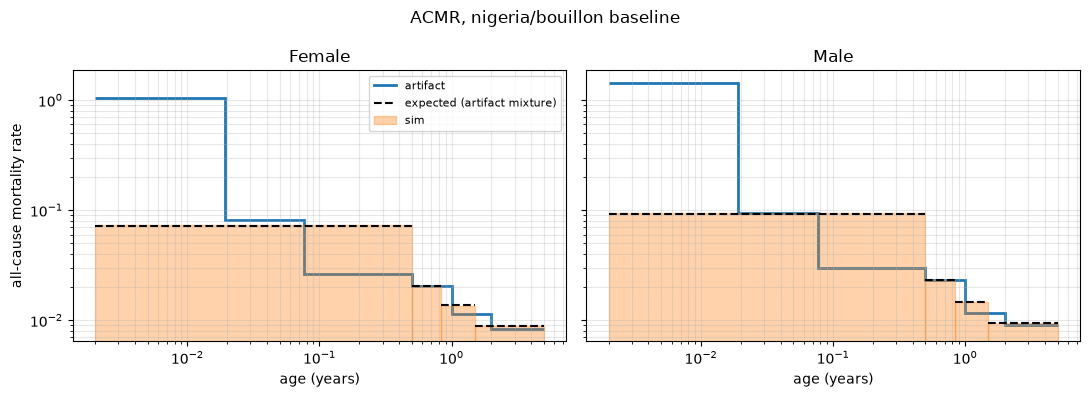

In [4]:
deaths = pd.read_parquet(paths.measure_path(results_dir, "deaths"))
pt = pd.read_parquet(paths.measure_path(results_dir, "person_time_population"))
cols = ["maternal_scenario", "child_scenario", "sex", "age_group"]
acmr = (deaths.groupby(cols).value.sum() / pt.groupby(cols).value.sum()).rename("sim")
acmr = acmr.xs(("baseline", "baseline")).reset_index()
sim_bins = {
    "0_to_5_months": (0.0, 0.5),
    "6_to_9_months": (0.5, 10 / 12),
    "10_to_17_months": (10 / 12, 1.5),
    "18_to_59_months": (1.5, 5.0),
}

art_acmr = art.load("cause.all_causes.cause_specific_mortality_rate")["draw_0"].reset_index()
art_acmr = art_acmr[art_acmr.age_start < 5].sort_values("age_start")


def mixture_rate(art_sex, lo, hi):
    """Deaths / person-time over [lo, hi) under the artifact's piecewise-constant hazard."""
    total_deaths = total_pt = 0.0
    survival = 1.0  # conditional on reaching lo; the constant cancels in the ratio
    for _, row in art_sex.iterrows():
        a, b = max(row.age_start, lo), min(row.age_end, hi)
        if a >= b:
            continue
        died = survival * (1 - np.exp(-row.draw_0 * (b - a)))
        total_deaths += died
        total_pt += died / row.draw_0
        survival -= died
    return total_deaths / total_pt


X_MIN = 2e-3
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, sex in zip(axes, ["Female", "Male"]):
    a = art_acmr[art_acmr.sex == sex]
    edges = np.append(a.age_start.values, a.age_end.values[-1]).clip(min=X_MIN)
    ax.stairs(a.draw_0.values, edges, baseline=None, color="C0", lw=2, label="artifact")
    for i, (age_group, (lo, hi)) in enumerate(sim_bins.items()):
        v = acmr.loc[(acmr.sex == sex) & (acmr.age_group == age_group), "sim"].iloc[0]
        ax.bar(max(lo, X_MIN), v, width=hi - max(lo, X_MIN), align="edge",
               color="C1", alpha=0.35, edgecolor="C1", label="sim" if i == 0 else None)
        ax.hlines(mixture_rate(a, lo, hi), max(lo, X_MIN), hi, color="k", ls="--",
                  lw=1.5, label="expected (artifact mixture)" if i == 0 else None)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(which="both", alpha=0.3)
    ax.set_title(sex)
    ax.set_xlabel("age (years)")
axes[0].set_ylabel("all-cause mortality rate")
axes[0].legend(fontsize=8)
fig.suptitle(f"ACMR, {location}/{vehicle} baseline")
fig.tight_layout()

The same comparison, numerically: `ratio` = observed / expected artifact mixture. `poisson_se`
is the floor on the ratio's sampling noise from the death count alone (between-seed clustering
makes the true noise somewhat larger), so ratios within ~2 of it are unremarkable.

In [5]:
q = "maternal_scenario == 'baseline' and child_scenario == 'baseline'"
rows = []
for sex in ["Female", "Male"]:
    a = art_acmr[art_acmr.sex == sex]
    for age_group, (lo, hi) in sim_bins.items():
        obs = acmr.loc[(acmr.sex == sex) & (acmr.age_group == age_group), "sim"].iloc[0]
        expected = mixture_rate(a, lo, hi)
        n_deaths = deaths.query(q).pipe(
            lambda d: d[(d.sex == sex) & (d.age_group == age_group)]
        ).value.sum()
        rows.append((sex, age_group, int(n_deaths), obs, expected, obs / expected))
summary = pd.DataFrame(
    rows, columns=["sex", "age_group", "deaths", "observed_acmr", "expected_acmr", "ratio"]
)
summary["poisson_se"] = 1 / np.sqrt(summary.deaths)
print(summary.round(4).to_string(index=False))

   sex       age_group  deaths  observed_acmr  expected_acmr  ratio  poisson_se
Female   0_to_5_months   91905         0.0738         0.0719 1.0271      0.0033
Female   6_to_9_months   17009         0.0205         0.0206 0.9964      0.0077
Female 10_to_17_months   21640         0.0136         0.0137 0.9921      0.0068
Female 18_to_59_months   73185         0.0088         0.0088 1.0022      0.0037
  Male   0_to_5_months  121820         0.0940         0.0929 1.0110      0.0029
  Male   6_to_9_months   19966         0.0232         0.0231 1.0032      0.0071
  Male 10_to_17_months   24147         0.0146         0.0145 1.0050      0.0064
  Male 18_to_59_months   81450         0.0095         0.0095 0.9959      0.0035


## Reading the `0_to_5_months` row: the expected side is composition-biased

The mixture expectation above models a closed cohort traversing the pooled bin in
continuous time. The simulation lives on a 4-day grid and attributes each step's
person-time and rate lookup to the age bin containing the simulant's age at the step
start -- so early neonatal receives 8 days of exposure (ages 0 and 4d) instead of 7,
and late neonatal 24 instead of 21. Within each GBD bin this cancels (observed deaths
and person-time shift together), but the *pooled* 0-5-month rate is composition-shifted
upward by ~+9% relative to any continuous-time expectation. The pooled ratio is
therefore uninterpretable on its own: it can mask a real deficit (nigeria: pooled 1.027
= composition +8.6% times a real ENN deficit x0.945) or manufacture an apparent excess
(india: pooled 1.06-1.07 despite every fine bin at or below 1.0).

The authoritative neonatal check is the fine-bin diagnostic: run the child sim with
`stratification: {fine_neonatal_age_bins: True}` in a branches file (50 seeds, ~13
minutes) and compare each GBD bin directly against the artifact rate. Model 1.2.4
evidence (F/M):

| bin | india | nigeria |
|---|---|---|
| early neonatal | 0.973 / 0.971 | **0.912 / 0.894** |
| late neonatal | 0.987 / 1.018 | 0.970 / 1.000 |
| 1-5 months | 0.995 / 0.975 | 0.986 / 0.991 |
| older bins | 0.95-1.02 | 0.98-1.02 |

The ENN deficits are real and conservative (the sim under-produces early neonatal
deaths): with the PAF calibrating the *instantaneous* rate at birth, the high-RR tail
depletes within the first week, so realized deaths/person-time falls below the GBD
period rate -- frailty selection, larger where (1-PAF) x RR x rate x step is larger
(nigeria ~-10%, india ~-3%). A follow-up candidate is calibrating the PAF so the PAF
simulation's *cumulative* ENN deaths match the artifact expectation instead.
